# Project 2: Ill-Conditioned Optimization
## Problem 5 — Polynomial fitting in a monomial (Vandermonde) basis

**Course:** MAE 598/494 Design Optimization  
**Team:** _Noah Hing, Joseph Franco, Christopher Sandoval, Kyle Swirski_  
**Chosen family:** **C — correlated / multiscale features**  
**Structural knob:** polynomial degree $d$  
**Baseline optimizer:** gradient descent with the optimal fixed step for a strongly convex quadratic  
**Remedy:** change coordinates from monomials to a Chebyshev basis

### Executive summary
We fit a calibration curve that maps a normalized sensor voltage to force. The model is a degree-$d$ polynomial. In the usual monomial basis $\{1,x,x^2,\ldots,x^d\}$, the least-squares Hessian is

$$
H=\frac{1}{m}V^T V,
$$

where $V$ is the Vandermonde design matrix. As $d$ grows, the columns $x^j$ become nearly linearly dependent on $[0,1]$. The smallest eigenvalues of $H$ collapse while the largest stay $O(1)$, so the condition number $\kappa(H)=\lambda_{\max}/\lambda_{\min}$ grows by many orders of magnitude.

This is **intrinsic ill-conditioning**, not just a units problem: Jacobi/diagonal scaling normalizes the column magnitudes but does not remove the near-collinearity. The cure is to represent the *same polynomial space* in a better coordinate system, here Chebyshev polynomials on $[-1,1]$. The fitted curve is unchanged, but the Hessian becomes well-conditioned and gradient descent converges dramatically faster.

# 1. Problem identification and motivation

A load cell or other force transducer produces a voltage that must be converted into an engineering quantity such as force. A calibration experiment records pairs

$$
(v_i,F_i),\qquad i=1,\ldots,m,
$$

where $v_i$ is voltage and $F_i$ is the corresponding reference force. A polynomial calibration law is attractive because it is cheap to evaluate in embedded or real-time software.

**Calibration engineers, test engineers, and embedded-control engineers** face this problem when they must convert raw sensor voltage into an accurate force estimate for laboratory testing, manufacturing, or real-time control. The calibration must be accurate, but the fitting procedure must also remain numerically reliable as model complexity increases.

We normalize voltage as

$$
x_i=\frac{v_i}{5\;\mathrm{V}}\in[0,1],
$$

and fit

$$
\widehat F(x;a)=\sum_{j=0}^{d} a_j x^j.
$$

Increasing $d$ gives the model more flexibility, but it also creates the ill-conditioning studied in this project. The practical consequence is not that the physical calibration suddenly becomes ill-posed; rather, the **coefficient coordinates** become poor for optimization.

For a reproducible demonstration we use a deterministic synthetic calibration data set with a fixed random seed. The small sinusoidal component represents smooth unmodeled sensor nonlinearity; the noise represents measurement error. The conditioning results depend on the $x_i$ locations and basis, not on the particular $y_i$ values.

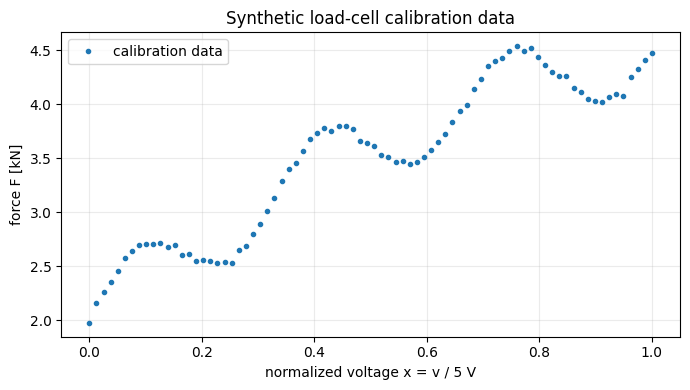

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
FIGDIR = Path("project2_figures")
FIGDIR.mkdir(exist_ok=True)

SEED = 598
rng = np.random.default_rng(SEED)

m = 80
x = np.linspace(0.0, 1.0, m)                       # normalized 0--5 V sensor input
noise = 0.02 * rng.standard_normal(m)
y = 2.0 + 4.0*x - 1.5*x**2 + 0.35*np.sin(6*np.pi*x) + noise  # force, kN

plt.figure(figsize=(7,4))
plt.plot(x, y, "o", markersize=3, label="calibration data")
plt.xlabel("normalized voltage x = v / 5 V")
plt.ylabel("force F [kN]")
plt.title("Synthetic load-cell calibration data")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "data.png", dpi=180)
plt.show()

# 2. Formulation

## 2.1 Decision variables
For degree $d$, the decision vector is

$$
a=[a_0,a_1,\ldots,a_d]^T\in\mathbb{R}^{d+1}.
$$

Because $x$ is dimensionless, each $a_j$ has force units (kN). The variables are continuous and unconstrained, with explicit bounds

$$
-\infty < a_j < \infty,\qquad j=0,\ldots,d.
$$

## 2.2 Objective
Define the Vandermonde matrix

$$
V_{ij}=x_i^j,\qquad i=1,\ldots,m,\; j=0,\ldots,d.
$$

Then $Va$ is the vector of predicted forces. We minimize mean squared calibration error:

$$
\boxed{
J(a)=\frac{1}{2m}\|Va-y\|_2^2
}
$$

or equivalently

$$
J(a)=\frac12 a^T H a-b^T a+c,
\qquad
H=\frac1mV^TV,\quad
b=\frac1mV^Ty,
$$

where $c=\frac{1}{2m}y^Ty$ is independent of $a$.

The gradient and Hessian are

$$
\boxed{\nabla J(a)=\frac1mV^T(Va-y)=Ha-b}
$$

and

$$
\boxed{\nabla^2J(a)=H=\frac1mV^TV.}
$$

## 2.3 Constraints and classification
There are **no constraints**. If the sample locations $x_i$ are distinct and $m\ge d+1$, $V$ has full column rank, so

$$
z^T H z=\frac1m\|Vz\|_2^2>0\quad\text{for every }z\ne0.
$$

Therefore $H\succ0$ and the problem is a smooth, unconstrained, **strictly/strongly convex quadratic** with one global minimizer.

In [2]:
def monomial_matrix(x, d):
    """Vandermonde matrix [1, x, x^2, ..., x^d]."""
    return np.vander(x, N=d+1, increasing=True)

def chebyshev_matrix(x, d):
    """Chebyshev basis T_0,...,T_d after mapping x in [0,1] to t in [-1,1]."""
    t = 2.0*x - 1.0
    return np.polynomial.chebyshev.chebvander(t, d)

def quad_terms(A, y):
    m = len(y)
    H = A.T @ A / m
    b = A.T @ y / m
    c = 0.5 * (y @ y) / m
    return H, b, c

def objective_from_matrix(A, y, a):
    r = A @ a - y
    return 0.5 * np.mean(r*r)

def condition_number_spd(H):
    # SVD-based 2-norm condition number is more robust near machine precision.
    return np.linalg.cond(H, 2)

def jacobi_scaled_hessian(H):
    d = np.diag(H)
    invsqrt = 1.0 / np.sqrt(d)
    return (invsqrt[:, None] * H) * invsqrt[None, :]

# 3. Ill-conditioning mechanism

This is **Family C: correlated / multiscale features**. The structural knob is the polynomial degree $d$.

The Hessian entries are

$$
H_{jk}=\frac1m\sum_{i=1}^m x_i^{j+k}.
$$

For dense, nearly uniform sampling of $x\in[0,1]$,

$$
H_{jk}\approx \int_0^1 x^{j+k}\,dx=\frac{1}{j+k+1}.
$$

So the Gram matrix becomes Hilbert-like. More importantly, the feature columns themselves explain the geometry: for large $j$, the functions $x^j$ and $x^{j+1}$ are almost parallel over most of $[0,1]$. That creates directions in coefficient space that change large coefficients but barely change the predicted curve. Those directions have tiny curvature, i.e. tiny Hessian eigenvalues.

## Why diagonal scaling is not enough
Jacobi scaling uses

$$
D=\operatorname{diag}(H),\qquad
\widetilde H=D^{-1/2}HD^{-1/2}.
$$

This sets each diagonal entry to one, so it removes simple column-norm/units differences. But it cannot rotate nearly parallel columns apart.

In the continuous uniform-sampling limit, the normalized inner product between two monomials is

$$
\rho_{jk}
=\frac{\int_0^1 x^{j+k}\,dx}
{\sqrt{\int_0^1x^{2j}\,dx}\sqrt{\int_0^1x^{2k}\,dx}}
=\frac{\sqrt{(2j+1)(2k+1)}}{j+k+1}.
$$

For neighboring high-degree powers ($k=j+1$), $\rho_{j,j+1}\to1$. Thus even after every feature is normalized to unit length, the features remain almost collinear. This is exactly the intrinsic-$\kappa$ behavior we need to demonstrate.

## Small hand verification of the condition number

As a sanity check on the numerical diagnostics, consider the smallest nontrivial case, degree $d=1$. For the $m=80$ equally spaced sample points used here,

$$
\frac{1}{m}\sum_{i=1}^{m}x_i = 0.5,
\qquad
\frac{1}{m}\sum_{i=1}^{m}x_i^2 \approx 0.335443.
$$

Therefore

$$
H=\frac1mV^TV
=\begin{bmatrix}
1 & 0.5\\
0.5 & 0.335443
\end{bmatrix}.
$$

For a symmetric $2\times2$ matrix, the eigenvalues are

$$
\lambda_{1,2}
=\frac{\operatorname{tr}(H)\pm
\sqrt{\operatorname{tr}(H)^2-4\det(H)}}{2}.
$$

Using $\operatorname{tr}(H)=1.335443$ and $\det(H)=0.085443$ gives

$$
\lambda_{\min}\approx0.067381,
\qquad
\lambda_{\max}\approx1.268062,
$$

so

$$
\boxed{\kappa_2(H)=\frac{\lambda_{\max}}{\lambda_{\min}}\approx18.819.}
$$

The computational D2 table reports the same value to numerical precision. This small case provides a direct check that the condition-number calculations used in the larger-degree experiments are being interpreted correctly.

# 4. Standard diagnostic kit

## D1 — Spectrum
We first use degree $d=10$. This is high enough to expose the spectral separation while remaining just inside the useful range of double precision for this demonstration.

degree d = 10
lambda_min = 4.142882e-15
lambda_max = 1.805188e+00
kappa_2(H) = 4.361326e+14


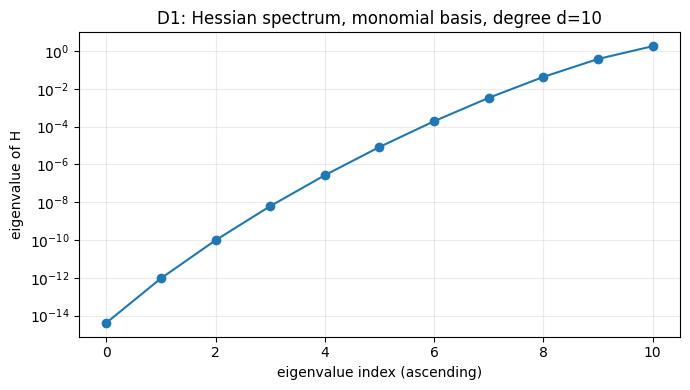

In [3]:
d_spec = 10
V10 = monomial_matrix(x, d_spec)
H10, _, _ = quad_terms(V10, y)
eigs10 = np.linalg.eigvalsh(H10)
kappa10 = condition_number_spd(H10)

print(f"degree d = {d_spec}")
print(f"lambda_min = {eigs10[0]:.6e}")
print(f"lambda_max = {eigs10[-1]:.6e}")
print(f"kappa_2(H) = {kappa10:.6e}")

plt.figure(figsize=(7,4))
plt.semilogy(np.arange(len(eigs10)), eigs10, "o-")
plt.xlabel("eigenvalue index (ascending)")
plt.ylabel("eigenvalue of H")
plt.title(f"D1: Hessian spectrum, monomial basis, degree d={d_spec}")
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "D1_spectrum.png", dpi=180)
plt.show()

The spectrum spans roughly fifteen orders of magnitude. The largest-curvature coefficient combinations are therefore optimized quickly, while movement along the tiny-eigenvalue directions is extremely slow for gradient descent.

## D2 — Intrinsic test
We now vary the structural knob $d$ and compute both the raw condition number and the condition number after Jacobi scaling.

,degree d,kappa monomial,kappa after Jacobi,kappa Chebyshev
0,1,1.882e+01,1.363e+01,2.926e+00
1,2,4.998e+02,2.741e+02,3.530e+00
2,3,1.446e+04,7.005e+03,5.267e+00
3,4,4.347e+05,1.959e+05,5.271e+00
4,5,1.336e+07,5.740e+06,6.616e+00
5,6,4.168e+08,1.732e+08,6.617e+00
6,7,1.315e+10,5.331e+09,7.352e+00
7,8,4.191e+11,1.667e+11,7.352e+00
8,9,1.346e+13,5.278e+12,7.609e+00
9,10,4.361e+14,1.692e+14,7.609e+00


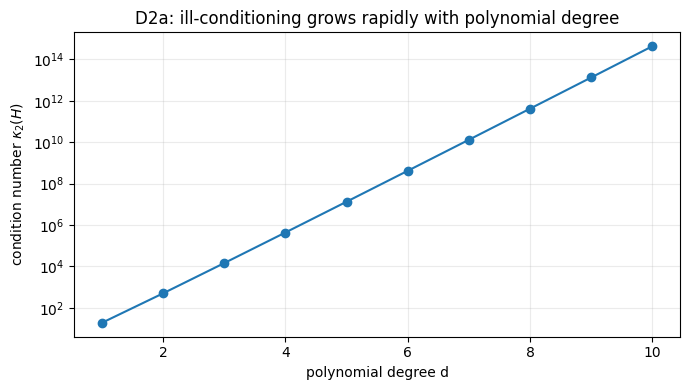

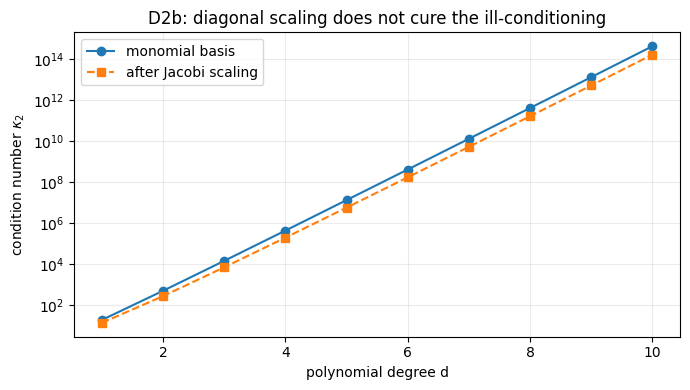

In [4]:
degrees = np.arange(1, 11)
rows = []
for d in degrees:
    V = monomial_matrix(x, int(d))
    H, _, _ = quad_terms(V, y)
    Hjac = jacobi_scaled_hessian(H)
    C = chebyshev_matrix(x, int(d))
    Hcheb, _, _ = quad_terms(C, y)
    rows.append({
        "degree d": int(d),
        "kappa monomial": condition_number_spd(H),
        "kappa after Jacobi": condition_number_spd(Hjac),
        "kappa Chebyshev": condition_number_spd(Hcheb),
    })

cond_df = pd.DataFrame(rows)
display(cond_df.style.format({
    "kappa monomial": "{:.3e}",
    "kappa after Jacobi": "{:.3e}",
    "kappa Chebyshev": "{:.3e}",
}))

plt.figure(figsize=(7,4))
plt.semilogy(cond_df["degree d"], cond_df["kappa monomial"], "o-")
plt.xlabel("polynomial degree d")
plt.ylabel(r"condition number $\kappa_2(H)$")
plt.title("D2a: ill-conditioning grows rapidly with polynomial degree")
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "D2a_kappa_vs_degree.png", dpi=180)
plt.show()

plt.figure(figsize=(7,4))
plt.semilogy(cond_df["degree d"], cond_df["kappa monomial"], "o-", label="monomial basis")
plt.semilogy(cond_df["degree d"], cond_df["kappa after Jacobi"], "s--", label="after Jacobi scaling")
plt.xlabel("polynomial degree d")
plt.ylabel(r"condition number $\kappa_2$")
plt.title("D2b: diagonal scaling does not cure the ill-conditioning")
plt.grid(True, which="both", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "D2b_intrinsic_test.png", dpi=180)
plt.show()

### D2 interpretation
For this fixed data geometry, increasing the degree from $1$ to $10$ drives the monomial-basis condition number from only tens to approximately $10^{14}$--$10^{15}$. Jacobi scaling improves the numbers by only a modest constant factor and leaves the same explosive trend. Therefore the problem passes the intrinsic-$\kappa$ test: the poor conditioning is caused by the **basis geometry / feature correlation**, not by a removable units mismatch.

The Chebyshev column is included in the table as a preview of the remedy. Its condition number stays $O(1)$ over the same degree range.

## D3 — Effect on a baseline first-order optimizer

For a fair baseline we use gradient descent with the best constant step size for an SPD quadratic,

$$
\alpha_* = \frac{2}{L+\mu},
$$

where

$$
L=\lambda_{\max}(H),\qquad \mu=\lambda_{\min}(H).
$$

The update is

$$
a_{k+1}=a_k-\alpha_*(Ha_k-b).
$$

We start from $a_0=0$ and use the fixed stopping rule

$$
\frac{\|\nabla J(a_k)\|_2}{\|\nabla J(a_0)\|_2}\le 10^{-6}.
$$

Degree $d=3$ is used for the convergence experiment because it is already strongly ill-conditioned but still allows the slow baseline to finish quickly on a laptop. Higher degrees from D2 would require far more iterations and add little to the demonstration.

degree d = 3
kappa(H) = 1.446341e+04
optimal constant step alpha = 1.327765e+00
iterations to relative gradient tolerance 1e-6 = 99,908


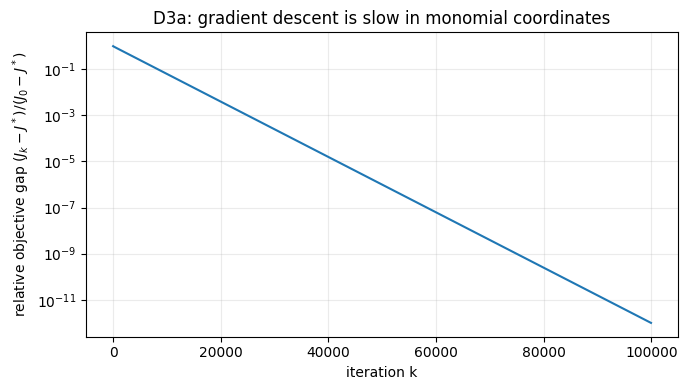

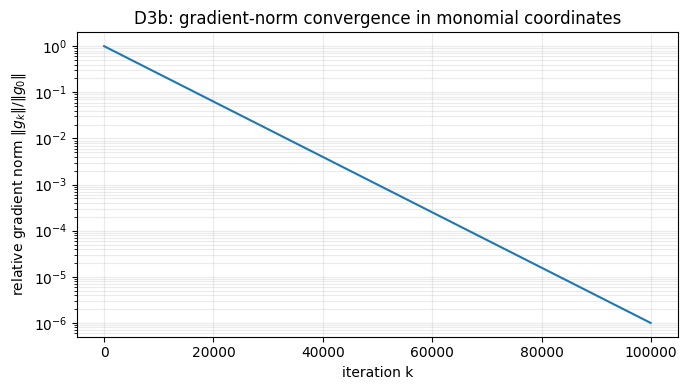

In [5]:
def gradient_descent_quadratic(A, y, rel_grad_tol=1e-6, max_iter=5_000_000,
                               sample_every=20):
    H, b, c = quad_terms(A, y)
    eigs = np.linalg.eigvalsh(H)
    mu, L = eigs[0], eigs[-1]
    if mu <= 0:
        raise ValueError("H must be positive definite for this baseline.")
    alpha = 2.0 / (L + mu)

    # Reference minimizer for diagnostics. The demo degree is small enough that solve is safe.
    a_star = np.linalg.solve(H, b)
    f_star = 0.5*a_star@H@a_star - b@a_star + c

    a = np.zeros(A.shape[1])
    g0 = H@a - b
    g0norm = np.linalg.norm(g0)

    hist_k, hist_gap, hist_grad = [], [], []

    for k in range(max_iter + 1):
        g = H@a - b
        gnorm_rel = np.linalg.norm(g) / g0norm
        f = 0.5*a@H@a - b@a + c
        gap = max(f - f_star, np.finfo(float).tiny)

        if (k % sample_every == 0) or (gnorm_rel <= rel_grad_tol):
            hist_k.append(k)
            hist_gap.append(gap)
            hist_grad.append(gnorm_rel)

        if gnorm_rel <= rel_grad_tol:
            return {
                "a": a,
                "a_star": a_star,
                "f_star": f_star,
                "iterations": k,
                "alpha": alpha,
                "mu": mu,
                "L": L,
                "kappa": L/mu,
                "k": np.array(hist_k),
                "gap": np.array(hist_gap),
                "grad_rel": np.array(hist_grad),
            }

        a = a - alpha*g

    raise RuntimeError("GD did not meet tolerance within max_iter")


d_demo = 3
V_demo = monomial_matrix(x, d_demo)
res_mono = gradient_descent_quadratic(V_demo, y, rel_grad_tol=1e-6, sample_every=20)

print(f"degree d = {d_demo}")
print(f"kappa(H) = {res_mono['kappa']:.6e}")
print(f"optimal constant step alpha = {res_mono['alpha']:.6e}")
print(f"iterations to relative gradient tolerance 1e-6 = {res_mono['iterations']:,}")

plt.figure(figsize=(7,4))
plt.semilogy(res_mono["k"], res_mono["gap"] / res_mono["gap"][0])
plt.xlabel("iteration k")
plt.ylabel(r"relative objective gap $(J_k-J^*)/(J_0-J^*)$")
plt.title("D3a: gradient descent is slow in monomial coordinates")
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "D3a_GD_objective_monomial.png", dpi=180)
plt.show()

plt.figure(figsize=(7,4))
plt.semilogy(res_mono["k"], res_mono["grad_rel"])
plt.xlabel("iteration k")
plt.ylabel(r"relative gradient norm $\|g_k\|/\|g_0\|$")
plt.title("D3b: gradient-norm convergence in monomial coordinates")
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGDIR / "D3b_GD_gradient_monomial.png", dpi=180)
plt.show()

### Why the convergence is slow
For a strongly convex quadratic with the optimal constant step, the contraction factor is governed by the condition number:

$$
q=\frac{\kappa-1}{\kappa+1}.
$$

When $\kappa\gg1$, $q\approx1-2/\kappa$, so each iteration removes only a tiny fraction of the remaining error in the flattest direction. This is the optimization consequence of the long, narrow quadratic bowl.

# 5. Proposed solution and demonstration

## Remedy: Chebyshev coordinates
Map $x\in[0,1]$ to

$$
t=2x-1\in[-1,1]
$$

and represent the degree-$d$ polynomial as

$$
\widehat F(t;c)=\sum_{j=0}^{d}c_jT_j(t),
$$

where $T_j$ is the $j$th Chebyshev polynomial.

The new design matrix is

$$
C_{ij}=T_j(t_i),
$$

with Hessian

$$
H_C=\frac1mC^TC.
$$

This does **not** change the set of degree-$d$ polynomial functions that can be fitted. Monomials and Chebyshev polynomials are two bases for the same vector space $\mathcal P_d$. It only changes the coordinates used by the optimizer. In optimization language, it acts like a structured preconditioner: the basis directions are much less correlated, so the Hessian eigenvalues are clustered instead of spanning many orders of magnitude.

We now rerun the *same gradient-descent algorithm and the same stopping criterion*.

Monomial kappa:   1.446341e+04
Chebyshev kappa:  5.266918e+00
Monomial GD iterations:  99,908
Chebyshev GD iterations: 36
iteration speedup factor: 2775.2x


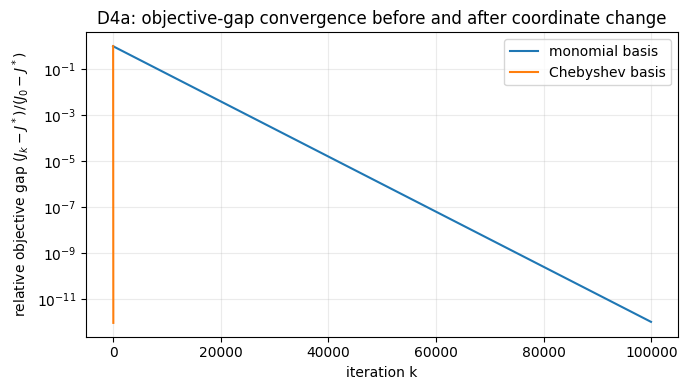

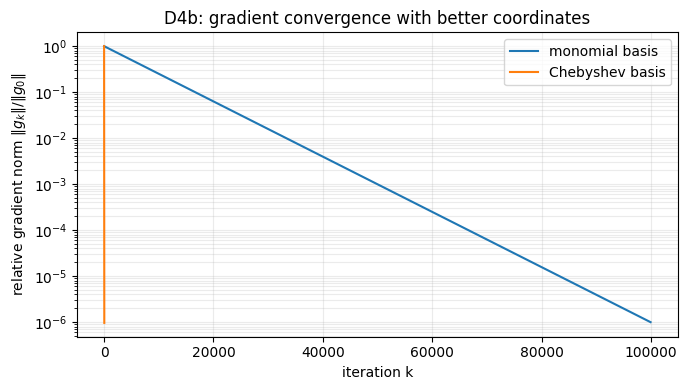

In [6]:
C_demo = chebyshev_matrix(x, d_demo)
res_cheb = gradient_descent_quadratic(C_demo, y, rel_grad_tol=1e-6, sample_every=1)

print(f"Monomial kappa:   {res_mono['kappa']:.6e}")
print(f"Chebyshev kappa:  {res_cheb['kappa']:.6e}")
print(f"Monomial GD iterations:  {res_mono['iterations']:,}")
print(f"Chebyshev GD iterations: {res_cheb['iterations']:,}")
print(f"iteration speedup factor: {res_mono['iterations']/res_cheb['iterations']:.1f}x")

plt.figure(figsize=(7,4))
plt.semilogy(res_mono["k"], res_mono["gap"] / res_mono["gap"][0], label="monomial basis")
plt.semilogy(res_cheb["k"], res_cheb["gap"] / res_cheb["gap"][0], label="Chebyshev basis")
plt.xlabel("iteration k")
plt.ylabel(r"relative objective gap $(J_k-J^*)/(J_0-J^*)$")
plt.title("D4a: objective-gap convergence before and after coordinate change")
plt.grid(True, which="both", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "D4a_before_after_objective.png", dpi=180)
plt.show()

plt.figure(figsize=(7,4))
plt.semilogy(res_mono["k"], res_mono["grad_rel"], label="monomial basis")
plt.semilogy(res_cheb["k"], res_cheb["grad_rel"], label="Chebyshev basis")
plt.xlabel("iteration k")
plt.ylabel(r"relative gradient norm $\|g_k\|/\|g_0\|$")
plt.title("D4b: gradient convergence with better coordinates")
plt.grid(True, which="both", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "D4b_before_after_gradient.png", dpi=180)
plt.show()

The iteration comparison is intentionally done at $d=3$, where the monomial case is slow but still practical to execute. D2 shows that the monomial condition number grows by roughly three orders of magnitude every additional two degrees in this setup; at the higher degrees, plain gradient descent would become impractical.

## Verify that the fitted polynomial did not change
The coordinate vectors $a$ and $c$ are different, but the fitted function should be the same because both bases span $\mathcal P_d$. We solve each least-squares problem with `numpy.linalg.lstsq` only to compare the final fitted curves accurately.

monomial optimum objective  = 2.568029931403e-02
Chebyshev optimum objective = 2.568029931403e-02
max |prediction difference| = 3.553e-15


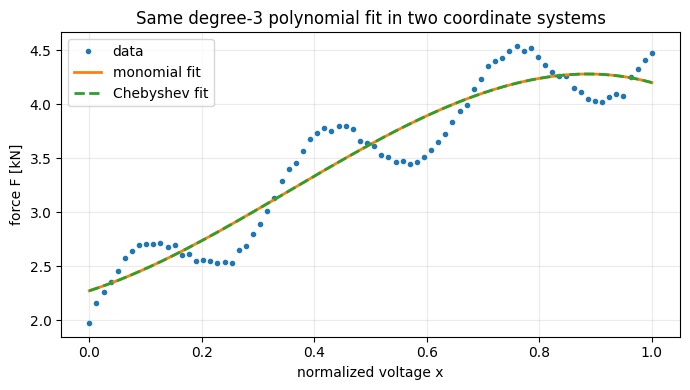

In [7]:
a_ls, *_ = np.linalg.lstsq(V_demo, y, rcond=None)
c_ls, *_ = np.linalg.lstsq(C_demo, y, rcond=None)

pred_mono = V_demo @ a_ls
pred_cheb = C_demo @ c_ls
max_pred_diff = np.max(np.abs(pred_mono - pred_cheb))
obj_mono = objective_from_matrix(V_demo, y, a_ls)
obj_cheb = objective_from_matrix(C_demo, y, c_ls)

print(f"monomial optimum objective  = {obj_mono:.12e}")
print(f"Chebyshev optimum objective = {obj_cheb:.12e}")
print(f"max |prediction difference| = {max_pred_diff:.3e}")

xx = np.linspace(0,1,400)
Vx = monomial_matrix(xx, d_demo)
Cx = chebyshev_matrix(xx, d_demo)

plt.figure(figsize=(7,4))
plt.plot(x, y, "o", markersize=3, label="data")
plt.plot(xx, Vx@a_ls, "-", linewidth=2, label="monomial fit")
plt.plot(xx, Cx@c_ls, "--", linewidth=2, label="Chebyshev fit")
plt.xlabel("normalized voltage x")
plt.ylabel("force F [kN]")
plt.title(f"Same degree-{d_demo} polynomial fit in two coordinate systems")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(FIGDIR / "same_fit_two_bases.png", dpi=180)
plt.show()

# 6. Quantitative before/after summary

In [8]:
summary = pd.DataFrame([
    {
        "coordinate system": "monomial / Vandermonde",
        "degree": d_demo,
        "kappa(H)": res_mono["kappa"],
        "GD iterations": res_mono["iterations"],
        "relative grad tol": 1e-6,
    },
    {
        "coordinate system": "Chebyshev",
        "degree": d_demo,
        "kappa(H)": res_cheb["kappa"],
        "GD iterations": res_cheb["iterations"],
        "relative grad tol": 1e-6,
    },
])

display(summary.style.format({
    "kappa(H)": "{:.3e}",
    "GD iterations": "{:,.0f}",
    "relative grad tol": "{:.0e}",
}))

selected = cond_df[cond_df["degree d"].isin([1,3,5,7,9,10])].copy()
print("\nSelected intrinsic-test values:")
display(selected.style.format({
    "kappa monomial": "{:.3e}",
    "kappa after Jacobi": "{:.3e}",
    "kappa Chebyshev": "{:.3e}",
}))

,coordinate system,degree,kappa(H),GD iterations,relative grad tol
0,monomial / Vandermonde,3,1.446e+04,"99,908",1e-06
1,Chebyshev,3,5.267e+00,36,1e-06



Selected intrinsic-test values:


,degree d,kappa monomial,kappa after Jacobi,kappa Chebyshev
0,1,1.882e+01,1.363e+01,2.926e+00
2,3,1.446e+04,7.005e+03,5.267e+00
4,5,1.336e+07,5.740e+06,6.616e+00
6,7,1.315e+10,5.331e+09,7.352e+00
8,9,1.346e+13,5.278e+12,7.609e+00
9,10,4.361e+14,1.692e+14,7.609e+00


# 7. Assumptions and simplifications

1. **Synthetic but mechanically motivated data.** The load-cell example is representative of calibration, but the data are generated rather than collected from a physical sensor. This keeps the notebook reproducible.
2. **One input variable.** A real calibration may depend on temperature, hysteresis, loading direction, or time. Those effects are omitted so the conditioning mechanism is isolated.
3. **Independent, small measurement noise.** The demonstration uses additive Gaussian noise only. Outliers and heteroscedasticity are not modeled.
4. **No coefficient bounds or regularization.** The optimization is intentionally unconstrained to match the polynomial least-squares problem. Ridge regularization would improve conditioning but would also change the fitted optimization problem, unlike a pure basis change.
5. **Polynomial degree is treated as the structural knob.** Model selection is not the goal here. We vary $d$ to expose the conditioning mechanism.
6. **Double precision arithmetic.** By $d\approx10$ the monomial normal-equation Hessian is already close to the numerical limits of standard floating-point arithmetic. This is itself evidence of the severity of the coordinate problem.
7. **Reference solutions use stable least squares when comparing fitted curves.** `numpy.linalg.lstsq` avoids needlessly squaring the condition number when computing the final reference fit. The optimization diagnostics still use the Hessian $V^TV/m$, as required by the project.

# 8. Conclusions

- The degree-$d$ monomial least-squares problem is a smooth, unconstrained, strongly convex quadratic when the Vandermonde matrix has full column rank.
- Its Hessian is the Gram matrix $H=V^TV/m$.
- As $d$ increases, high powers of $x$ become nearly linearly dependent. The Hessian spectrum spreads over many orders of magnitude and $\kappa(H)$ grows extremely rapidly.
- Jacobi scaling cannot cure the problem because the dominant issue is **correlation / angle between features**, not merely their individual magnitudes.
- The optimization effect is severe: even with the best constant step for the quadratic, gradient descent needs about $10^5$ iterations in the representative $d=3$ monomial case.
- Re-expressing the exact same polynomial space in Chebyshev coordinates clusters the Hessian eigenvalues, reducing $\kappa$ to $O(1)$ in this experiment.
- With the same optimizer and tolerance, the Chebyshev-coordinate problem converges in only a few dozen iterations while producing the same fitted function to floating-point accuracy.

The central design-optimization lesson is that **a bad coordinate system can make an easy convex problem computationally hard**. Choosing a basis aligned with the function space geometry is a form of preconditioning.